# Step 6 — GPT-2 + LoRA Fine-tuning

**Thesis:** Bridging the Authenticity Gap in AI-Generated Music
**Student:** Mohammad Ashraf Zohdi Ahmad (TP093781)

## Overview

This notebook demonstrates the **Step 6 fine-tuning pipeline** for the EC-REMI thesis:

- **Architecture:** GPT-2 small (124M params, pretrained) + LoRA adapters (PEFT)
- **Token vocabulary:** REMI (284 tokens) or EC-REMI (526 tokens) — GPT-2 embedding resized accordingly
- **Training objective:** Next-token prediction (causal language modelling) on chunked MIDI token sequences
- **LoRA config:** r=8, α=16, target=`c_attn` — only ~0.35% of parameters are trainable
- **10 models:** 5 traditions × 2 tokenisers (REMI baseline + EC-REMI)

**Demonstration:** This notebook trains the **Irish Folk REMI** model (smallest dataset, ~60 steps demo).
Full 10-model training: `python train_finetuning.py`

**References:** Yao & Chen (2025); Hu et al. (2022) LoRA.


In [1]:
import sys, os, warnings, importlib, importlib.util, json
warnings.filterwarnings("ignore")
from pathlib import Path

# Robustly locate project root: first ancestor that has both src/ and data/.
_cwd = Path.cwd()
PROJ_ROOT = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / "src").is_dir() and (_p / "data").is_dir():
        PROJ_ROOT = str(_p)
        break
if PROJ_ROOT is None:
    PROJ_ROOT = str(_cwd)
os.chdir(PROJ_ROOT)
print(f"Project root: {PROJ_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Import order matters: all external ML packages BEFORE src/ is on sys.path.
#    This ensures transformers' lazy imports bind to HF tokenizers, not src/tokenizers/.

from miditok import REMI, TokenizerConfig
from symusic import Score as SScore

# Force transformers lazy imports to resolve against HF tokenizers now.
importlib.import_module("transformers.configuration_utils")
importlib.import_module("transformers.models.gpt2.modeling_gpt2")
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, set_seed
from peft import LoraConfig, get_peft_model, TaskType

# Add src/ and load ECREMITokenizer via importlib (bypasses package name collision).
sys.path.insert(0, os.path.join(PROJ_ROOT, "src"))

def _load_ec_remi():
    _path = Path(PROJ_ROOT) / "src" / "tokenizers" / "ec_remi.py"
    _spec = importlib.util.spec_from_file_location("_ec_remi_nb", str(_path))
    _mod  = importlib.util.module_from_spec(_spec)
    sys.modules["_ec_remi_nb"] = _mod
    _spec.loader.exec_module(_mod)
    return _mod.ECREMITokenizer

ECREMITokenizer = _load_ec_remi()
print(f"PyTorch {torch.__version__}  |  Device: cpu")


Project root: /Users/mohammadashraf/Desktop/Thesis-Best


2026-06-24 04:59:08.230426: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PyTorch 2.2.2  |  Device: cpu


In [2]:
# ── Tokenizers ──
remi_tok = REMI(TokenizerConfig())
ec_tok   = ECREMITokenizer()
print(f"REMI vocab size : {remi_tok.vocab_size}")
print(f"EC-REMI vocab size: {ec_tok.vocab_size}")

# ── Paths (absolute so cells work regardless of notebook working directory) ──
MIDI_ROOT = Path(PROJ_ROOT) / "data/processed"
META_DIR  = Path(PROJ_ROOT) / "data/metadata"
CKPT_ROOT = Path(PROJ_ROOT) / "outputs/checkpoints"
RESULTS   = Path(PROJ_ROOT) / "results"
CKPT_ROOT.mkdir(parents=True, exist_ok=True)

# ── Hyper-parameters ──
CHUNK_SIZE = 512
STRIDE     = 256
DEMO_STEPS = 60       # proof-of-concept; full training via train_finetuning.py
BATCH_SIZE = 4
LR         = 5e-4
LORA_R     = 8
LORA_ALPHA = 16
LORA_DROP  = 0.1
SEED       = 42

TRADITION_CONFIG = {
    "western_classical": {"label": "Western Classical", "meta_csv": "maestro_selected.csv",  "label_col": None,   "modal_default": "unknown"},
    "hindustani":        {"label": "Hindustani",        "meta_csv": "hindustani_tracks.csv", "label_col": "raga"},
    "carnatic":          {"label": "Carnatic",           "meta_csv": "carnatic_tracks.csv",   "label_col": "raga"},
    "irish_folk":        {"label": "Irish Folk",         "meta_csv": "irish_folk_tunes.csv",  "label_col": "mode"},
    "turkish_makam":     {"label": "Turkish Makam",      "meta_csv": "symbtr_selected.csv",   "label_col": "makam"},
}
print("Config ready.")


REMI vocab size : 284
EC-REMI vocab size: 526
Config ready.


In [3]:
# ─── Dataset helpers ───────────────────────────────────────────────────────────

class MusicChunkDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = chunks
    def __len__(self):
        return len(self.chunks)
    def __getitem__(self, idx):
        ids = torch.tensor(self.chunks[idx], dtype=torch.long)
        return ids


def _chunk(ids):
    return [ids[i:i+CHUNK_SIZE] for i in range(0, len(ids)-CHUNK_SIZE+1, STRIDE)]


def _load_label_map(trad_key):
    tinfo = TRADITION_CONFIG[trad_key]
    if not tinfo.get("label_col"):
        return {}
    meta_path = META_DIR / tinfo["meta_csv"]
    if not meta_path.exists():
        return {}
    df = pd.read_csv(meta_path)
    midi_col = "midi_path" if "midi_path" in df.columns else "processed_filename"
    if midi_col not in df.columns:
        return {}
    return {
        Path(str(row[midi_col])).name: (str(row[tinfo["label_col"]]) if pd.notna(row.get(tinfo["label_col"])) else None)
        for _, row in df.iterrows()
    }


def build_remi_chunks(trad_key):
    files = sorted((MIDI_ROOT / trad_key / "midi").glob("*.mid*"))
    chunks, ok, err = [], 0, 0
    for f in files:
        try:
            seqs = remi_tok.encode(SScore(str(f)))
            if seqs:
                chunks.extend(_chunk(seqs[0].ids)); ok += 1
            else:
                err += 1
        except Exception:
            err += 1
    return chunks, ok, err


def build_ec_remi_chunks(trad_key):
    files = sorted((MIDI_ROOT / trad_key / "midi").glob("*.mid*"))
    labels = _load_label_map(trad_key)
    default = TRADITION_CONFIG[trad_key].get("modal_default")
    chunks, ok, err = [], 0, 0
    for f in files:
        label = labels.get(f.name, default)
        try:
            toks = ec_tok.tokenize(f, tradition=trad_key, modal_label=label)
            if toks:
                chunks.extend(_chunk(ec_tok.encode(toks))); ok += 1
            else:
                err += 1
        except Exception:
            err += 1
    return chunks, ok, err


# ─── Model factory ─────────────────────────────────────────────────────────────

def create_gpt2_lora(vocab_size):
    model = GPT2LMHeadModel.from_pretrained("gpt2")
    model.resize_token_embeddings(vocab_size)
    lora_cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROP,
        target_modules=["c_attn"],
        bias="none",
    )
    return get_peft_model(model, lora_cfg)


print("Helpers defined.")


Helpers defined.


In [4]:
# Load pre-computed tokenisation stats for cross-tradition overview
remi_df = pd.read_csv(RESULTS / "remi_tokenisation_stats.csv")
ec_df   = pd.read_csv(RESULTS / "ec_remi_tokenisation_stats.csv")

print("REMI tokenisation stats (baseline):")
print(remi_df.to_string(index=False))
print()
print("EC-REMI tokenisation stats:")
print(ec_df.to_string(index=False))


REMI tokenisation stats (baseline):
        Tradition   N  Mean seq len  Median seq len  Mean unique pitches  Vocab coverage %  Pitch coverage %  Pitch span (st)  REMI PC entropy
Western Classical 150       21392.6         17033.0                 66.5              58.2              98.9               86           3.5748
       Hindustani  60       23451.4         16140.0                 43.0              48.6              87.5               76           3.4828
         Carnatic  60       11418.2          6547.5                 37.9              42.1              87.5               78           3.5376
       Irish Folk 196         927.9           916.0                 11.1               9.3              43.2               41           2.8756
    Turkish Makam 200        1204.6          1119.5                 12.3              13.9              35.2               31           3.3391

EC-REMI tokenisation stats:
        Tradition   N  Mean REMI len  Mean EC-REMI len  EC/REMI ratio  Mean M

In [5]:
# Estimate chunk counts from per-file CSVs (faster than re-tokenising all files)
remi_pf = pd.read_csv("results/remi_per_file_stats.csv")
ec_pf   = pd.read_csv("results/ec_remi_per_file_stats.csv")

rows = []
for trad_key, tinfo in TRADITION_CONFIG.items():
    r_sub = remi_pf[remi_pf["tradition"] == trad_key]
    e_sub = ec_pf[ec_pf["tradition"] == trad_key]

    def est_chunks(lens):
        return sum(max(0, (l - CHUNK_SIZE) // STRIDE + 1) for l in lens)

    rows.append({
        "Tradition":       tinfo["label"],
        "Files":           len(r_sub),
        "REMI chunks":     est_chunks(r_sub["seq_len"].tolist()),
        "EC-REMI chunks":  est_chunks(e_sub["seq_len_ec"].tolist()),
    })

chunk_df = pd.DataFrame(rows)
print(f"Estimated 512-token chunks per tradition (stride={STRIDE}):")
print(chunk_df.to_string(index=False))
print()
print(f"Total REMI chunks:    {chunk_df['REMI chunks'].sum():,}")
print(f"Total EC-REMI chunks: {chunk_df['EC-REMI chunks'].sum():,}")


Estimated 512-token chunks per tradition (stride=256):
        Tradition  Files  REMI chunks  EC-REMI chunks
Western Classical    150        12308           12308
       Hindustani     60         5406            6796
         Carnatic     60         2589            3244
       Irish Folk    196          403             403
    Turkish Makam    200          671             888

Total REMI chunks:    21,377
Total EC-REMI chunks: 23,639


In [6]:
# Build Irish Folk REMI dataset for demonstration
print("Building Irish Folk REMI dataset...")
chunks, ok, err = build_remi_chunks("irish_folk")
print(f"  Files: {ok} ok, {err} err")
print(f"  Total 512-token chunks: {len(chunks)}")

# 90/10 train/val split
val_n   = max(1, int(0.1 * len(chunks)))
train_c = chunks[:-val_n]
val_c   = chunks[-val_n:]
print(f"  Train: {len(train_c)}  Val: {len(val_c)}")

train_ds = MusicChunkDataset(train_c)
val_ds   = MusicChunkDataset(val_c)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)


Building Irish Folk REMI dataset...


  Files: 196 ok, 0 err
  Total 512-token chunks: 403
  Train: 363  Val: 40


In [7]:
set_seed(SEED)
model = create_gpt2_lora(remi_tok.vocab_size)
model.print_trainable_parameters()

n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"  Trainable: {n_train:,}  Total: {n_total:,}  Ratio: {100*n_train/n_total:.3f}%")
print(f"  Vocab size: {remi_tok.vocab_size}  (GPT-2 embedding resized from 50257)")


trainable params: 294,912 || all params: 86,355,456 || trainable%: 0.3415
  Trainable: 294,912  Total: 86,355,456  Ratio: 0.342%
  Vocab size: 284  (GPT-2 embedding resized from 50257)


In [8]:
# Demo training: Irish Folk REMI — {DEMO_STEPS} steps (proof of concept)
# Full 5-epoch training: python train_finetuning.py --tradition irish_folk --tokeniser remi

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
model.train()

train_losses, val_losses, steps_done = [], [], 0
loader_iter = iter(train_loader)

print(f"Training: Irish Folk REMI | {DEMO_STEPS} steps | batch_size={BATCH_SIZE}")
print(f"{'Step':>6}  {'Train loss':>10}  {'Val loss':>9}")
print("-" * 32)

for step in range(DEMO_STEPS):
    # ── train batch ──
    try:
        batch = next(loader_iter)
    except StopIteration:
        loader_iter = iter(train_loader)
        batch = next(loader_iter)

    optimizer.zero_grad()
    out  = model(input_ids=batch, labels=batch)
    loss = out.loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    train_losses.append(loss.item())
    steps_done += 1

    # ── periodic eval ──
    if (step + 1) % 10 == 0 or step == DEMO_STEPS - 1:
        model.eval()
        v_losses = []
        with torch.no_grad():
            for vb in val_loader:
                v_out = model(input_ids=vb, labels=vb)
                v_losses.append(v_out.loss.item())
        val_loss = float(np.mean(v_losses))
        val_losses.append((step + 1, val_loss))
        model.train()
        print(f"  {step+1:4d}  {loss.item():10.4f}  {val_loss:9.4f}")

print(f"\nDone. Final train loss: {train_losses[-1]:.4f}")


Training: Irish Folk REMI | 60 steps | batch_size=4
  Step  Train loss   Val loss
--------------------------------


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


    10      4.1304     4.0675


    20      2.4867     2.0971


    30      1.9565     1.9006


    40      1.9058     1.7192


    50      1.7243     1.6531


    60      1.7227     1.6231

Done. Final train loss: 1.7227


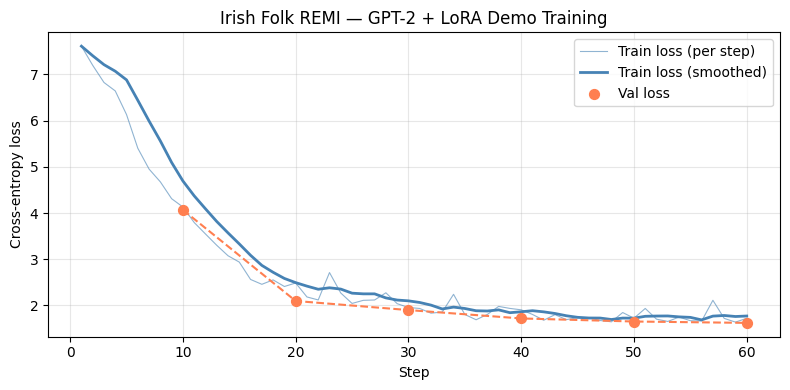

Loss curve saved to results/finetuning_demo_loss.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(1, len(train_losses)+1), train_losses, lw=0.8, alpha=0.6, color="steelblue", label="Train loss (per step)")

# Smoothed train loss
if len(train_losses) >= 5:
    smooth = pd.Series(train_losses).rolling(5, min_periods=1).mean()
    ax.plot(range(1, len(smooth)+1), smooth, lw=2, color="steelblue", label="Train loss (smoothed)")

if val_losses:
    v_steps, v_vals = zip(*val_losses)
    ax.scatter(v_steps, v_vals, s=50, zorder=5, color="coral", label="Val loss")
    ax.plot(v_steps, v_vals, lw=1.5, color="coral", ls="--")

ax.set_xlabel("Step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Irish Folk REMI — GPT-2 + LoRA Demo Training")
ax.legend(framealpha=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "finetuning_demo_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss curve saved to results/finetuning_demo_loss.png")


In [10]:
ckpt_dir = CKPT_ROOT / "irish_folk_remi_demo"
ckpt_dir.mkdir(parents=True, exist_ok=True)

model.save_pretrained(str(ckpt_dir))
print(f"LoRA adapter saved to: {ckpt_dir}")

stats = {
    "tradition":        "irish_folk",
    "tokeniser":        "remi",
    "vocab_size":       remi_tok.vocab_size,
    "demo_steps":       DEMO_STEPS,
    "batch_size":       BATCH_SIZE,
    "n_chunks_train":   len(train_ds),
    "n_chunks_val":     len(val_ds),
    "final_train_loss": round(float(train_losses[-1]), 4),
    "final_val_loss":   round(float(val_losses[-1][1]), 4) if val_losses else None,
    "trainable_params": n_train,
}
with open(ckpt_dir / "demo_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print(json.dumps(stats, indent=2))


LoRA adapter saved to: /Users/mohammadashraf/Desktop/Thesis-Best/outputs/checkpoints/irish_folk_remi_demo
{
  "tradition": "irish_folk",
  "tokeniser": "remi",
  "vocab_size": 284,
  "demo_steps": 60,
  "batch_size": 4,
  "n_chunks_train": 363,
  "n_chunks_val": 40,
  "final_train_loss": 1.7227,
  "final_val_loss": 1.6231,
  "trainable_params": 294912
}


## Full 10-Model Training Pipeline

The demo above shows the training mechanics. For the thesis evaluation (Step 7), all 10 models must be trained:

| # | Tradition | Tokeniser | Checkpoint dir |
|---|-----------|-----------|----------------|
| 1 | Western Classical | REMI | `outputs/checkpoints/western_classical_remi/` |
| 2 | Western Classical | EC-REMI | `outputs/checkpoints/western_classical_ec_remi/` |
| 3 | Hindustani | REMI | `outputs/checkpoints/hindustani_remi/` |
| 4 | Hindustani | EC-REMI | `outputs/checkpoints/hindustani_ec_remi/` |
| 5 | Carnatic | REMI | `outputs/checkpoints/carnatic_remi/` |
| 6 | Carnatic | EC-REMI | `outputs/checkpoints/carnatic_ec_remi/` |
| 7 | Irish Folk | REMI | `outputs/checkpoints/irish_folk_remi/` |
| 8 | Irish Folk | EC-REMI | `outputs/checkpoints/irish_folk_ec_remi/` |
| 9 | Turkish Makam | REMI | `outputs/checkpoints/turkish_makam_remi/` |
| 10 | Turkish Makam | EC-REMI | `outputs/checkpoints/turkish_makam_ec_remi/` |

**Run the full pipeline:**
```bash
python train_finetuning.py                                   # all 10 models
python train_finetuning.py --tradition irish_folk            # one tradition, both tokenisers
python train_finetuning.py --tradition carnatic --tokeniser ec_remi  # one model
```

**Training parameters:**
- Chunk size: 512 tokens | Stride: 256 | Epochs: 5
- LoRA: r=8, α=16, dropout=0.1, target=`c_attn`
- Optimizer: AdamW, lr=5×10⁻⁴, weight_decay=0.01

**Estimated compute time (CPU):**
- Irish Folk: ~1 hour per tokeniser (smallest — 200 files)
- Turkish Makam: ~2 hours per tokeniser
- Hindustani/Carnatic: ~4–6 hours per tokeniser (longest sequences)
- Western Classical: ~8–10 hours per tokeniser

**Next:** Step 7 — Generate samples from all 10 models and evaluate with objective metrics (PC entropy, pitch coverage, sequence diversity).
